In [ ]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
# Creating a sample student dataset

student_data = {
    'Study_Hours': [1, 2, 3, 4, 5, 6, 7, 8, 2, 5, 7, 9, 4, 6, 8],
    'Attendance': [60, 65, 70, 75, 80, 85, 90, 95, 68, 82, 88, 97, 73, 86, 92],
    'Previous_Marks': [40, 45, 50, 55, 60, 65, 70, 75, 48, 62, 72, 85, 58, 68, 78],
    'Marks': [42, 47, 52, 58, 63, 69, 76, 82, 49, 65, 78, 90, 60, 72, 84]
}

df = pd.DataFrame(student_data)

df.to_csv("student_marks.csv", index=False)

df

,Study_Hours,Attendance,Previous_Marks,Marks
0,1,60,40,42
1,2,65,45,47
2,3,70,50,52
3,4,75,55,58
4,5,80,60,63
5,6,85,65,69
6,7,90,70,76
7,8,95,75,82
8,2,68,48,49
9,5,82,62,65


In [ ]:
# Display first 5 rows

df.head()


,Study_Hours,Attendance,Previous_Marks,Marks
0,1,60,40,42
1,2,65,45,47
2,3,70,50,52
3,4,75,55,58
4,5,80,60,63


In [ ]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Study_Hours     15 non-null     int64
 1   Attendance      15 non-null     int64
 2   Previous_Marks  15 non-null     int64
 3   Marks           15 non-null     int64
dtypes: int64(4)
memory usage: 612.0 bytes


In [ ]:
# Statistical summary

df.describe()

,Study_Hours,Attendance,Previous_Marks,Marks
count,15.000000,15.000000,15.000000,15.000000
mean,5.133333,80.400000,62.066667,65.800000
std,2.445599,11.425535,12.941995,14.580809
min,1.000000,60.000000,40.000000,42.000000
25%,3.500000,71.500000,52.500000,55.000000
50%,5.000000,82.000000,62.000000,65.000000
75%,7.000000,89.000000,71.000000,77.000000
max,9.000000,97.000000,85.000000,90.000000


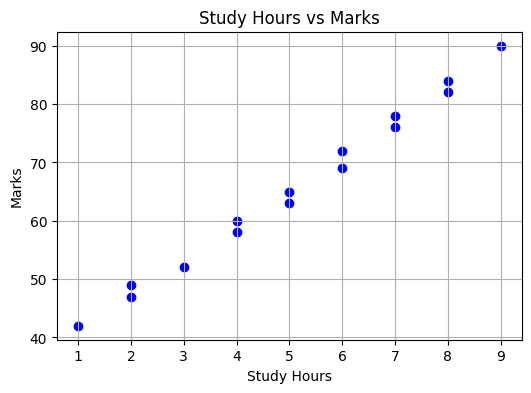

In [ ]:
# Scatter Plot

plt.figure(figsize=(6,4))
plt.scatter(df['Study_Hours'], df['Marks'], color='blue')
plt.title("Study Hours vs Marks")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.grid(True)
plt.show()

In [ ]:
# Selecting input features and target

X = df[['Study_Hours', 'Attendance', 'Previous_Marks']]
y = df['Marks']

print("Input Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input Features:
   Study_Hours  Attendance  Previous_Marks
0            1          60              40
1            2          65              45
2            3          70              50
3            4          75              55
4            5          80              60

Target:
0    42
1    47
2    52
3    58
4    63
Name: Marks, dtype: int64


In [ ]:
# Splitting the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))

Training Data: 12
Testing Data: 3


In [ ]:
# Creating and training the Linear Regression model

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
# Predicting marks for test data

y_pred = model.predict(X_test)

print("Predicted Marks:")
print(y_pred)

Predicted Marks:
[65.56716862 91.53734899 40.34196869]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Comparing Actual and Predicted Marks

result = pd.DataFrame({
    'Actual Marks': y_test.values,
    'Predicted Marks': y_pred
})

result

,Actual Marks,Predicted Marks
0,65,65.567169
1,90,91.537349
2,42,40.341969


In [ ]:
# Evaluating the model

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("R2 Score:", round(r2, 2))

Mean Absolute Error: 1.25
R2 Score: 1.0


In [ ]:
# Correlation between columns

correlation = df.corr()
print(correlation)

                Study_Hours  Attendance  Previous_Marks     Marks
Study_Hours        1.000000    0.992352        0.992674  0.996348
Attendance         0.992352    1.000000        0.982818  0.986661
Previous_Marks     0.992674    0.982818        1.000000  0.997855
Marks              0.996348    0.986661        0.997855  1.000000


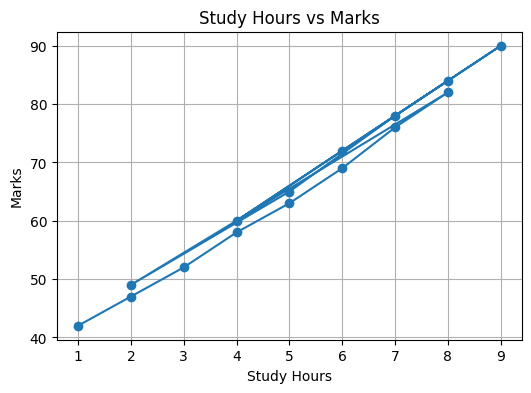

In [ ]:
# Line Graph

plt.figure(figsize=(6,4))
plt.plot(df['Study_Hours'], df['Marks'], marker='o')
plt.title("Study Hours vs Marks")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.grid(True)
plt.show()

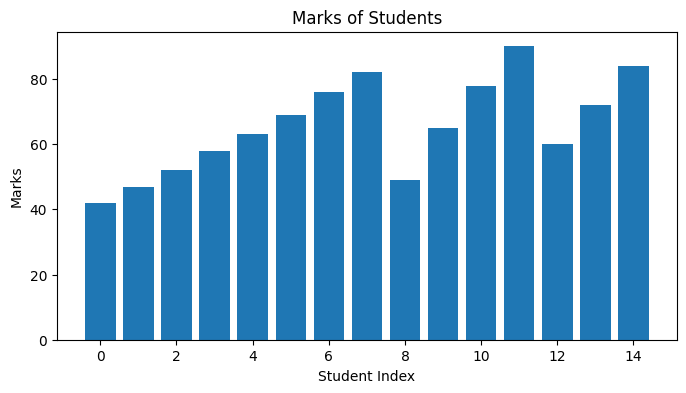

In [ ]:
# Bar Chart

plt.figure(figsize=(8,4))
plt.bar(df.index, df['Marks'])
plt.title("Marks of Students")
plt.xlabel("Student Index")
plt.ylabel("Marks")
plt.show()

In [50]:
# Predict marks for new student

study_hours = float(input("Enter Study Hours: "))
attendance = float(input("Enter Attendance Percentage: "))
previous_marks = float(input("Enter Previous Marks: "))

new_data = pd.DataFrame({
    'Study_Hours': [study_hours],
    'Attendance': [attendance],
    'Previous_Marks': [previous_marks]
})

predicted_marks = model.predict(new_data)

final_marks = max(0, min(100, predicted_marks[0]))

print("Predicted Marks:", round(final_marks, 2))

Enter Study Hours: 6
Enter Attendance Percentage: 83
Enter Previous Marks: 90
Predicted Marks: 90.42


## Conclusion

This project predicts student marks using a Linear Regression model.
The model uses Study Hours, Attendance, and Previous Marks as input features.
The trained model can predict marks for new student data based on the learned patterns.